# 控制流
- 顺序结构
- 分支结构

## 顺序结构
### add_edge()
### START、END节点
- END节点可以省略
### add_sequence()
- 入参为一个可执行对象列表，自动编排节点顺序，省去`add_node()`和`add_edge()操作`
- 示例：
    - `add_sequence([node1, node2])`
        -  其中node1和node2为函数，这里作为2个节点，节点名默认为函数名
        - 等价于:
            ```python
                    builder.add_node("node_a", node_a)
                    builder.add_node("node_b", node_b)
                    builder.add_edge("node_a", "node_b")
            ```

## 分支结构
- 静态分支: 下游候选节点在编译器完全确定
    - 并行节点
    - 条件分支
        - `add_conditional_edges()`

### 条件分支
- add_condiotnal_edges() 源码
    - ```python
        def add_conditional_edges(
            self,
            source: str,
            path: Callable[..., Hashable | Sequence[Hashable]]
            | Callable[..., Awaitable[Hashable | Sequence[Hashable]]]
            | Runnable[Any, Hashable | Sequence[Hashable]],
            path_map: dict[Hashable, str] | list[str] | None = None,
        ) -> Self:
      ```
        - source: 源节点
        - path: 路由规则，返回节点名称或tag名称
        - path_map: tag和node的映射。在某些情况下，path_map还可以辅助渲染流程图，在`条件条件单个节点`案例中，如果没有path_map,条件边并不知道下一个节点是什么，所以`node1`和`node2`会游离在图外。
        - 如果path_map为None，path必须返回节点名称，如果path_map定义了tag和映射，可以返回tag
        - tag可以描述业务，而节点名仍然可以保持工程化命名，便于维护和理解

#### 条件跳转单个节点

In [ ]:
from IPython.core.display import display_png, Image
from langchain_core.messages import HumanMessage
from typing import TypedDict, Literal, Sequence, Annotated, List
from langgraph.constants import START, END
from langgraph.graph import StateGraph
from loguru import logger
from torch.distributed.elastic.agent.server import WorkerState

from common import init_simple_dashscope_model

model = init_simple_dashscope_model('qwen3.7-plus')


class StateSchema(TypedDict):
    topic: str
    type: str
    poem_res: str
    joke_res: str
    public_res: str


def public_node(state: StateSchema) -> StateSchema:
    return {
        "public_res": "This is a public response"
    }

def node1(state: StateSchema) -> StateSchema:
    resp = model.invoke([
        HumanMessage(f"写一个关于 {state['topic']} 的笑话")
    ])
    return {
        "poem_res": resp
    }


def node2(state: StateSchema) -> StateSchema:
    resp = model.invoke([
        HumanMessage(f"写一个关于 {state['topic']} 的七言诗")
    ])
    return {
        "joke_res": resp
    }

# router 返回 tag，不是节点名
def router(state: StateSchema) -> List[Literal['写诗节点', '笑话节点', 'public']]:
    if '诗' in state['type']:
        return ["写诗节点", 'public']
    else:
        return ["笑话节点", 'public']


# tag → 节点名 的映射
path_map = {
    "写诗节点": "node2",
    "笑话节点": "node1",
    "public": "public_node",
}


state_graph = StateGraph(state_schema=StateSchema)
state_graph.add_node("node1", node1)
state_graph.add_node("node2", node2)
state_graph.add_node("public_node", public_node)

state_graph.add_conditional_edges(START, router, path_map)
state_graph.add_edge('node1', END)
state_graph.add_edge('node2', END)
state_graph.add_edge('public_node', END)

graph = state_graph.compile()
poem = graph.invoke(
    {
        "topic": "功夫猫",
        "type": "诗"
    }
)
print(poem)

display_png(Image(graph.get_graph().draw_mermaid_png()))

#### 条件跳转多个节点
- 条件边的`router`函数可以返回序列

{'topic': '功夫猫', 'type': '诗', 'joke_res': AIMessage(content='为您创作了两首不同风格的关于“功夫猫”的七言绝句，一首侧重**武侠宗师风范**，另一首侧重**灵动俏皮的反差萌**，供您选择：\n\n### 其一：武侠宗师风（侧重意境与气场）\n**狸奴隐迹翠微中，**\n**纵跃飞檐气若虹。**\n**铁爪凌空惊百兽，**\n**江湖独步傲群雄。**\n\n* **赏析**：“狸奴”是古人对猫的雅称。这首诗将猫咪隐于竹林翠微之中，展现其深藏不露的高手气质。后两句描写它施展轻功飞檐走壁，铁爪挥出时气势如虹，连百兽为之震惊，点出它“独步江湖”的武林宗师地位。\n\n---\n\n### 其二：灵动俏皮风（侧重体态与反差萌）\n**绒爪轻舒步点霜，**\n**飞身倒挂探檐廊。**\n**莫看娇躯才数尺，**\n**降龙伏虎自称王。**\n\n* **赏析**：这首诗更突出“猫”本身的可爱特性与“功夫”的结合。前两句描写它毛茸茸的爪子轻点寒霜，还能像武林高手一样飞身倒挂在屋檐之下。后两句笔锋一转，带着几分俏皮与傲气：别看它身躯娇小只有几尺长，却有着降龙伏虎的绝世武功，自封为林间大王。', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 3574, 'prompt_tokens': 21, 'total_tokens': 3595, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 3256, 'rejected_prediction_tokens': None, 'text_tokens': 3574}, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0, 'text_tokens': 21}}, 'model_provider': 'openai', 'model_name': 'qwen3.7-plus', 'system_fing

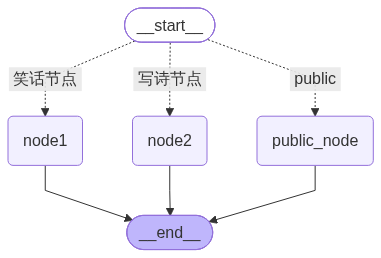

In [7]:
from IPython.core.display import display_png, Image
from langchain_core.messages import HumanMessage
from typing import TypedDict, Literal, Sequence
from langgraph.constants import START, END
from langgraph.graph import StateGraph

from common import init_simple_dashscope_model

model = init_simple_dashscope_model('qwen3.7-plus')


class StateSchema(TypedDict):
    topic: str
    type: str
    poem_res: str
    joke_res: str
    public_res: str


def public_node(state: StateSchema) -> StateSchema:
    return {
        "public_res": "This is a public response"
    }

def node1(state: StateSchema) -> StateSchema:
    resp = model.invoke([
        HumanMessage(f"写一个关于 {state['topic']} 的笑话")
    ])
    return {
        "poem_res": resp
    }


def node2(state: StateSchema) -> StateSchema:
    resp = model.invoke([
        HumanMessage(f"写一个关于 {state['topic']} 的七言诗")
    ])
    return {
        "joke_res": resp
    }

# router 返回 tag，不是节点名
def router(state: StateSchema) -> Sequence[Literal['写诗节点', '笑话节点', 'public']]:
    if '诗' in state['type']:
        return ["写诗节点", 'public']
    else:
        return ["笑话节点", 'public']

# tag → 节点名 的映射
path_map = {
    "写诗节点": "node2",
    "笑话节点": "node1",
    "public": "public_node"
}

state_graph = StateGraph(state_schema=StateSchema)
state_graph.add_node("node1", node1)
state_graph.add_node("node2", node2)
state_graph.add_node("public_node", public_node)
state_graph.add_conditional_edges(START, router, path_map)
state_graph.add_edge('node1', END)
state_graph.add_edge('public_node', END)
state_graph.add_edge('node2', END)

graph = state_graph.compile()
poem = graph.invoke(
    {
        "topic": "功夫猫",
        "type": "诗"
    }
)
print(poem)
#
# joke = graph.invoke(
#     {
#         "topic": "布偶狗",
#         "type": "笑话"
#     }
# )
# print(joke)

display_png(Image(graph.get_graph().draw_mermaid_png()))

### defer node execution
- 延迟节点，通过`add_node(defer=True)`设置
- 原理：
    - `defer=True`的节点在编译图时阶段会创建`LastValueAfterFinish`通道，而普通节点是在`EphemeralValue`通道
        ```python
            self.channels[branch_channel] = (
                LastValueAfterFinish(Any)
                if node.defer
                else EphemeralValue(Any, guard=False))
        ```
    - 在常规流程执行完毕会，会调用所有`Channel`的`finish()`，而`EphemeralValue`不会触发动作，只有`LastValueAfterFinish`会将内部的`finisehd`标记为`True`,
        并返回`True`,这个时候`Channel`的`is_available`同样变为`True`,延迟通道会被添加到`update_channels`中，从而在额外的`superstep`触发`defer`节点
            -
- 场景：
    - 统一结果汇总或结果校验
    - 日志记录
    - 审计
    - 收尾清理

2026-08-10 17:58:19.699 | INFO     | __main__:final_report_node:52 - 任务节点全部执行完毕，诗 未生成，笑话 已生成


{'topic': '功夫猫', 'type': '诗', 'joke_res': AIMessage(content='这是一首为您创作的关于“功夫猫”的七言绝句。诗中融合了武侠的意境与猫咪本身的灵动可爱：\n\n**《七绝·功夫猫》**\n\n**灵猫隐迹卧松阴，**\n**忽展轻功跃竹林。**\n**太极柔拳惊落叶，**\n**收功依旧理霜襟。**\n\n**【诗意赏析】**\n*   **第一句**：写猫咪平时深藏不露，像一位隐世的高手，慵懒地卧在松树的阴影下休息。\n*   **第二句**：画风一转，展现其绝顶的“轻功”，身形一闪便轻盈地跃入竹林之中（致敬经典功夫电影中的竹林比武）。\n*   **第三句**：描写其具体的武功招式，打出的太极柔拳看似绵软，却带着强劲的气劲，连飘落的树叶都被拳风惊动。\n*   **第四句**：点睛之笔，写“反差萌”。一套绝世武功打完之后，这位“武林宗师”瞬间变回了一只普通的小猫，若无其事地舔舐、梳理着自己雪白的胸毛（霜襟）。动静结合，既有宗师风范，又保留了猫咪的娇憨。', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 3243, 'prompt_tokens': 21, 'total_tokens': 3264, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 2982, 'rejected_prediction_tokens': None, 'text_tokens': 3243}, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0, 'text_tokens': 21}}, 'model_provider': 'openai', 'model_name': 'qwen3.7-plus', 'system_fingerprint': None, 'id': 'chatcmpl-8d0e4128-7a35-96cc-a214-061865

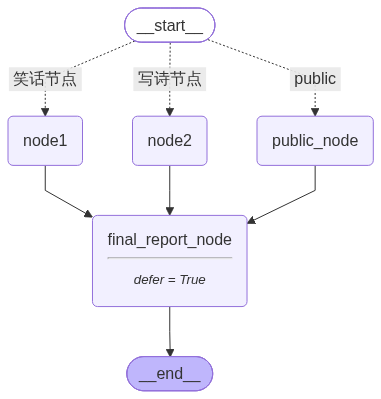

In [12]:
from IPython.core.display import display_png, Image
from langchain_core.messages import HumanMessage
from typing import TypedDict, Literal, Sequence
from langgraph.constants import START, END
from langgraph.graph import StateGraph
from loguru import logger

from common import init_simple_dashscope_model

model = init_simple_dashscope_model('qwen3.7-plus')


class StateSchema(TypedDict):
    topic: str
    type: str
    poem_res: str
    joke_res: str
    public_res: str


def public_node(state: StateSchema) -> StateSchema:
    return {
        "public_res": "This is a public response"
    }

def node1(state: StateSchema) -> StateSchema:
    resp = model.invoke([
        HumanMessage(f"写一个关于 {state['topic']} 的笑话")
    ])
    return {
        "poem_res": resp
    }


def node2(state: StateSchema) -> StateSchema:
    resp = model.invoke([
        HumanMessage(f"写一个关于 {state['topic']} 的七言诗")
    ])
    return {
        "joke_res": resp
    }

# router 返回 tag，不是节点名
def router(state: StateSchema) -> Sequence[Literal['写诗节点', '笑话节点', 'public']]:
    if '诗' in state['type']:
        return ["写诗节点", 'public']
    else:
        return ["笑话节点", 'public']

# defer节点
def final_report_node(state: StateSchema) -> StateSchema:
    logger.info(f"任务节点全部执行完毕，诗 {'已生成' if state.get('poem_res') else '未生成'}，笑话 {'已生成' if state.get('joke_res') else '未生成'}")


# tag → 节点名 的映射
path_map = {
    "写诗节点": "node1",
    "笑话节点": "node2",
    "public": "public_node",
}


state_graph = StateGraph(state_schema=StateSchema)
state_graph.add_node("node1", node1)
state_graph.add_node("node2", node2)
state_graph.add_node("public_node", public_node)
state_graph.add_node("final_report_node", final_report_node, defer=True)

state_graph.add_conditional_edges(START, router, path_map)
state_graph.add_edge('node1', 'final_report_node')
state_graph.add_edge('node2', 'final_report_node')
state_graph.add_edge('public_node', 'final_report_node')
state_graph.add_edge('final_report_node', END)

graph = state_graph.compile()
poem = graph.invoke(
    {
        "topic": "功夫猫",
        "type": "诗"
    }
)
print(poem)
#
# joke = graph.invoke(
#     {
#         "topic": "布偶狗",
#         "type": "笑话"
#     }
# )
# print(joke)

display_png(Image(graph.get_graph().draw_mermaid_png()))

## 动态分支
### Send扇出
- `Send`,运行时动态扇出多个任务，并行执行
    - 参数:
        - node:待启动的下游节点名称
        - arg:传递给下游节点的参数，通常是私有状态。

{'topic': '人生', 'result': ['**《逆旅》**\n\n我们赤手空拳地来，\n像一滴雨，偶然落入尘寰的杯盏。\n起初，世界是巨大的迷宫，\n我们在啼哭中，寻找第一束光的方向。\n\n少年时，以为人生是笔直的跑道，\n风在耳边呼啸，梦想比天高。\n我们追逐地平线，\n以为翻过那座山，就是永恒的春天。\n\n后来，岁月学会了折纸，\n将棱角折叠进沉默的口袋。\n我们在得失之间摆渡，\n在爱恨的潮汐里，修补破损的帆。\n有些路，走着走着就断了；\n有些人，看着看着就散了。\n原来，遗憾也是生命的一种纹理，\n像树轮，记录着风雨，也支撑着生长。\n\n中年是一场漫长的和解，\n与平庸和解，与孤独和解，\n与那个曾经不可一世的自己和解。\n我们不再急于证明什么，\n只是静静地看着花开，听着雪落，\n明白平凡才是唯一的真相。\n\n直到暮色四合，白发如霜，\n回首望去，来路已模糊成一片苍茫。\n那些曾以为过不去的坎，\n如今都成了脚下平缓的土丘。\n那些曾痛彻心扉的离别，\n也化作了记忆里温柔的月光。\n\n人生啊，不过是一场借来的旅行，\n行囊空空，却装满了故事。\n终点并非虚无，\n而是回归最初的宁静——\n像那滴雨，最终汇入大海，\n无声，无息，却拥有了整片汪洋。', '人生就像是一个巨大的在线购物网站。\n\n你年轻时拼命往购物车里加东西：梦想、爱情、豪宅、环游世界……\n\n到了中年，你发现购物车已经满了，于是开始纠结地删删减减。\n\n等到老了，你终于下定决心只保留最珍贵的几样东西，点击“结算”。\n\n结果系统弹出一个提示框：\n**“抱歉，您的‘时间’余额不足，且不支持退款。”** 🛒⏳', '# 剧本标题：《回声》\n\n**类型**：剧情 / 奇幻 / 人生哲理\n**时长**：短片（约 15-20 分钟）\n**核心主题**：人生不是寻找答案的过程，而是学会与问题共处的旅程。\n\n---\n\n### **人物介绍**\n\n*   **林远 (30岁)**：一名陷入职业瓶颈和存在主义危机的建筑师。焦虑、疲惫，渴望找到人生的“终极蓝图”。\n*   **老陈 (70岁)**：一家旧书店兼钟表修理店的店主。温和、睿智，眼神中透着岁月的沉淀。\n*   **小林 (8岁)**：林远的童年化身（仅出现在回忆或超现实场景中）。天真、好奇，

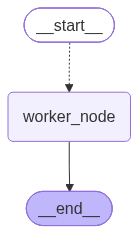

In [19]:
from langgraph.types import Send
from operator import add
from common import init_simple_dashscope_model
from typing import Annotated

model = init_simple_dashscope_model('qwen3.7-plus', extra_body={
        "enable_thinking": False
    })


class AllOverState(TypedDict):
    topic: str
    result: Annotated[list[str], add]

class WokerState(TypedDict):
    prompt: str

def worker_node(state: WokerState):
    prompt = state.get('prompt')
    resp = model.invoke([
        HumanMessage(content=prompt)
    ])
    return {
        "result": [resp.content]
    }

def router(state: AllOverState) -> Sequence[Send]:
    prompt_temp = "写一个关于 {topic} 的{content_type}"
    task = ['诗', '笑话', '剧本']
    prompt_list = [
        prompt_temp.format(
            topic=state['topic'],
            content_type=t
        ) for t in task
    ]
    return [
        Send(
          "worker_node",
            {
                "prompt": prompt
            }
        ) for prompt in prompt_list
    ]


state_graph = StateGraph(state_schema=AllOverState)

state_graph.add_node("worker_node", worker_node)
state_graph.add_conditional_edges(
    START,
    router,
    path_map=['worker_node']
)
state_graph.add_edge('worker_node', END)

graph = state_graph.compile()

resp = graph.invoke(
    {
        "topic": "人生",
    }
)

print(resp)

png_bytes = graph.get_graph().draw_mermaid_png()
img = Image(png_bytes)
display_png(img)



### 动态跳转Command
- Command: 在节点内部做逻辑判断同时指定跳转的下游节点
- Command4个参数：
    - update: 图状态更新内容，dict类型
    - goto: 指定跳转的节点名称
    - graph: 存在子图时，指定跳转发生在哪一层图中
    - resume: 用于恢复被中断的图执行，常见于`Human-in-the-loop`场景

## 多分支汇聚

### 静态扇入